# MWE 17 - Solver-options benchmark for constant and variable viscosity

This notebook benchmarks the solver configurations currently available in `voids`.

It has two sections:
1. Constant-viscosity linear solves
2. Pressure-dependent viscosity solves using both Picard and damped Newton

Scientific scope:
- the geometry is fixed so the comparison isolates solver behavior
- all runs report the same physical quantity (`Kabs`) and are compared against a reference solve
- the PyAMG path is treated as a linear preconditioner, not as a different physical model

In [8]:
from __future__ import annotations

import sys
from pathlib import Path
from statistics import median
from time import perf_counter

import matplotlib

if "ipykernel" not in sys.modules:
    matplotlib.use("Agg")
import matplotlib.pyplot as plt
import pandas as pd

from voids.examples import make_cartesian_mesh_network
from voids.physics.singlephase import (
    FluidSinglePhase,
    PressureBC,
    SinglePhaseOptions,
    solve,
)
from voids.physics.thermo import TabulatedWaterViscosityModel

plt.style.use("seaborn-v0_8-whitegrid")

In [9]:
def find_notebooks_base() -> Path:
    """Return the notebook root used for saved figures and CSV artifacts."""

    from os import environ

    if "VOIDS_NOTEBOOKS_PATH" in environ:
        return Path(environ["VOIDS_NOTEBOOKS_PATH"]).expanduser().resolve()

    cwd = Path.cwd().resolve()
    for candidate in (cwd, *cwd.parents):
        if (candidate / "notebooks").is_dir() and (
            candidate / "jupytext.toml"
        ).exists():
            return candidate / "notebooks"
    return cwd


NET = make_cartesian_mesh_network(
    (35, 35),
    spacing=1.0,
    thickness=1.0,
    pore_radius=0.22,
    throat_radius=0.09,
)
CONDUCTANCE_MODEL = "valvatne_blunt"
LINEAR_BC = PressureBC("inlet_xmin", "outlet_xmax", pin=1.0, pout=0.0)
NONLINEAR_BC = PressureBC("inlet_xmin", "outlet_xmax", pin=8.0e6, pout=5.0e6)
THERMO_MODEL = TabulatedWaterViscosityModel.from_backend(
    "thermo",
    temperature=298.15,
    pressure_points=192,
)
REFERENCE_MU = THERMO_MODEL.reference_viscosity(
    pin=NONLINEAR_BC.pin, pout=NONLINEAR_BC.pout
)
REPEATS = 3
NOTEBOOKS_BASE = find_notebooks_base()
OUTPUT_DIR = NOTEBOOKS_BASE / "outputs" / "17_mwe_solver_options_benchmark"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

constant_configs = {
    "direct": SinglePhaseOptions(conductance_model=CONDUCTANCE_MODEL, solver="direct"),
    "cg": SinglePhaseOptions(
        conductance_model=CONDUCTANCE_MODEL,
        solver="cg",
        solver_parameters={"rtol": 1.0e-10, "maxiter": 3_000},
    ),
    "cg_pyamg": SinglePhaseOptions(
        conductance_model=CONDUCTANCE_MODEL,
        solver="cg",
        solver_parameters={
            "rtol": 1.0e-10,
            "maxiter": 3_000,
            "preconditioner": "pyamg",
        },
    ),
    "gmres": SinglePhaseOptions(
        conductance_model=CONDUCTANCE_MODEL,
        solver="gmres",
        solver_parameters={"rtol": 1.0e-10, "maxiter": 800, "restart": 80},
    ),
    "gmres_pyamg": SinglePhaseOptions(
        conductance_model=CONDUCTANCE_MODEL,
        solver="gmres",
        solver_parameters={
            "rtol": 1.0e-10,
            "maxiter": 800,
            "restart": 80,
            "preconditioner": "pyamg",
        },
    ),
}
variable_configs = {
    "picard_direct": SinglePhaseOptions(
        conductance_model=CONDUCTANCE_MODEL,
        solver="direct",
        nonlinear_solver="picard",
        nonlinear_pressure_tolerance=1.0e-10,
    ),
    "picard_gmres_pyamg": SinglePhaseOptions(
        conductance_model=CONDUCTANCE_MODEL,
        solver="gmres",
        nonlinear_solver="picard",
        nonlinear_pressure_tolerance=1.0e-10,
        solver_parameters={
            "rtol": 1.0e-10,
            "maxiter": 800,
            "restart": 80,
            "preconditioner": "pyamg",
        },
    ),
    "newton_direct": SinglePhaseOptions(
        conductance_model=CONDUCTANCE_MODEL,
        solver="direct",
        nonlinear_solver="newton",
        nonlinear_pressure_tolerance=1.0e-10,
    ),
    "newton_gmres": SinglePhaseOptions(
        conductance_model=CONDUCTANCE_MODEL,
        solver="gmres",
        nonlinear_solver="newton",
        nonlinear_pressure_tolerance=1.0e-10,
        solver_parameters={"rtol": 1.0e-10, "maxiter": 800, "restart": 80},
    ),
    "newton_gmres_pyamg": SinglePhaseOptions(
        conductance_model=CONDUCTANCE_MODEL,
        solver="gmres",
        nonlinear_solver="newton",
        nonlinear_pressure_tolerance=1.0e-10,
        solver_parameters={
            "rtol": 1.0e-10,
            "maxiter": 800,
            "restart": 80,
            "preconditioner": "pyamg",
        },
    ),
}

In [10]:
def benchmark_case(
    *,
    fluid: FluidSinglePhase,
    bc: PressureBC,
    axis: str,
    options: SinglePhaseOptions,
    repeats: int,
) -> tuple[dict[str, float], object]:
    """Run one solver configuration multiple times and summarize timing."""

    times: list[float] = []
    last_result = None
    for _ in range(repeats):
        tic = perf_counter()
        last_result = solve(
            NET,
            fluid=fluid,
            bc=bc,
            axis=axis,
            options=options,
        )
        times.append(perf_counter() - tic)
    assert last_result is not None
    return (
        {
            "time_median_s": median(times),
            "time_min_s": min(times),
            "time_max_s": max(times),
        },
        last_result,
    )


def finalize_figure(fig) -> None:
    """Show figures in notebooks and close them in non-interactive script runs."""

    backend = matplotlib.get_backend().lower()
    if "agg" in backend:
        plt.close(fig)
    else:
        plt.show()


def summarize_configs(
    *,
    title: str,
    fluid: FluidSinglePhase,
    bc: PressureBC,
    configs: dict[str, SinglePhaseOptions],
    reference_label: str,
) -> pd.DataFrame:
    """Benchmark a set of solver configurations and compare against one reference run."""

    rows: list[dict[str, float | str]] = []
    reference_kabs = None
    reference_q = None
    for label, options in configs.items():
        timing, result = benchmark_case(
            fluid=fluid,
            bc=bc,
            axis="x",
            options=options,
            repeats=REPEATS,
        )
        if label == reference_label:
            reference_kabs = result.permeability["x"]
            reference_q = result.total_flow_rate
        rows.append(
            {
                "section": title,
                "config": label,
                "solver": options.solver,
                "nonlinear_solver": options.nonlinear_solver,
                "kabs": result.permeability["x"],
                "Q": result.total_flow_rate,
                "residual_norm": result.residual_norm,
                "mass_balance_error": result.mass_balance_error,
                "linear_info": float(result.solver_info.get("info", 0)),
                "nonlinear_iterations": float(
                    result.solver_info.get("nonlinear_iterations", 0)
                ),
                **timing,
            }
        )
    assert reference_kabs is not None and reference_q is not None
    df = pd.DataFrame(rows)
    df["kabs_rel_diff_to_reference"] = (df["kabs"] - reference_kabs) / reference_kabs
    df["Q_rel_diff_to_reference"] = (df["Q"] - reference_q) / reference_q
    return df

## Benchmark design

This notebook is intended to answer two separate numerical questions:
- which linear solver/preconditioner pair is most efficient for the constant-viscosity pressure solve
- whether Picard or Newton is the better outer strategy once viscosity depends on pressure

The same mesh network is used throughout, and each configuration is benchmarked multiple times so the
tables report representative rather than single-shot timings.

In [11]:
design_df = pd.DataFrame(
    {
        "quantity": [
            "mesh_shape",
            "pore_radius",
            "throat_radius",
            "conductance_model",
            "constant_reference_viscosity [Pa s]",
            "nonlinear_pin [MPa]",
            "nonlinear_pout [MPa]",
            "repeats_per_configuration",
        ],
        "value": [
            str((35, 35)),
            0.22,
            0.09,
            CONDUCTANCE_MODEL,
            REFERENCE_MU,
            NONLINEAR_BC.pin / 1.0e6,
            NONLINEAR_BC.pout / 1.0e6,
            REPEATS,
        ],
    }
)
design_df

,quantity,value
0,mesh_shape,"(35, 35)"
1,pore_radius,0.22
2,throat_radius,0.09
3,conductance_model,valvatne_blunt
4,constant_reference_viscosity [Pa s],0.000889
5,nonlinear_pin [MPa],8.0
6,nonlinear_pout [MPa],5.0
7,repeats_per_configuration,3


## Constant-viscosity benchmark

This is the easiest case for AMG because the pressure matrix is the standard linear elliptic operator.

In [12]:
constant_df = summarize_configs(
    title="constant_viscosity",
    fluid=FluidSinglePhase(viscosity=REFERENCE_MU),
    bc=LINEAR_BC,
    configs=constant_configs,
    reference_label="direct",
)
constant_df
constant_df.to_csv(OUTPUT_DIR / "constant_solver_benchmark.csv", index=False)

In [13]:
constant_ranked = constant_df.sort_values("time_median_s")[
    [
        "config",
        "time_median_s",
        "kabs_rel_diff_to_reference",
        "Q_rel_diff_to_reference",
        "preconditioner" if "preconditioner" in constant_df.columns else "solver",
    ]
]
constant_ranked

,config,time_median_s,kabs_rel_diff_to_reference,Q_rel_diff_to_reference,solver
1,cg,0.008954,-3.860261e-14,-3.847776e-14,cg
0,direct,0.010435,0.000000e+00,0.000000e+00,direct
2,cg_pyamg,0.013541,1.311848e-09,1.311848e-09,cg
4,gmres_pyamg,0.013940,4.458657e-10,4.458657e-10,gmres
3,gmres,0.020286,-2.588130e-14,-2.582936e-14,gmres


## Variable-viscosity benchmark

The nonlinear runs use absolute pressures and the same thermodynamic viscosity model as the previous
notebook. Here the question is not only linear-solver speed but also whether Picard or Newton is the
better outer strategy.

In [14]:
variable_df = summarize_configs(
    title="variable_viscosity",
    fluid=FluidSinglePhase(viscosity_model=THERMO_MODEL),
    bc=NONLINEAR_BC,
    configs=variable_configs,
    reference_label="newton_direct",
)
variable_df
variable_df.to_csv(OUTPUT_DIR / "variable_solver_benchmark.csv", index=False)

In [15]:
variable_ranked = variable_df.sort_values("time_median_s")[
    [
        "config",
        "time_median_s",
        "nonlinear_iterations",
        "kabs_rel_diff_to_reference",
        "Q_rel_diff_to_reference",
    ]
]
variable_ranked

,config,time_median_s,nonlinear_iterations,kabs_rel_diff_to_reference,Q_rel_diff_to_reference
2,newton_direct,0.018524,2.0,0.000000e+00,0.000000e+00
4,newton_gmres_pyamg,0.026856,2.0,0.000000e+00,0.000000e+00
3,newton_gmres,0.029893,2.0,0.000000e+00,0.000000e+00
0,picard_direct,0.051843,3.0,2.522333e-13,2.522264e-13
1,picard_gmres_pyamg,0.068730,3.0,2.836144e-09,2.836144e-09


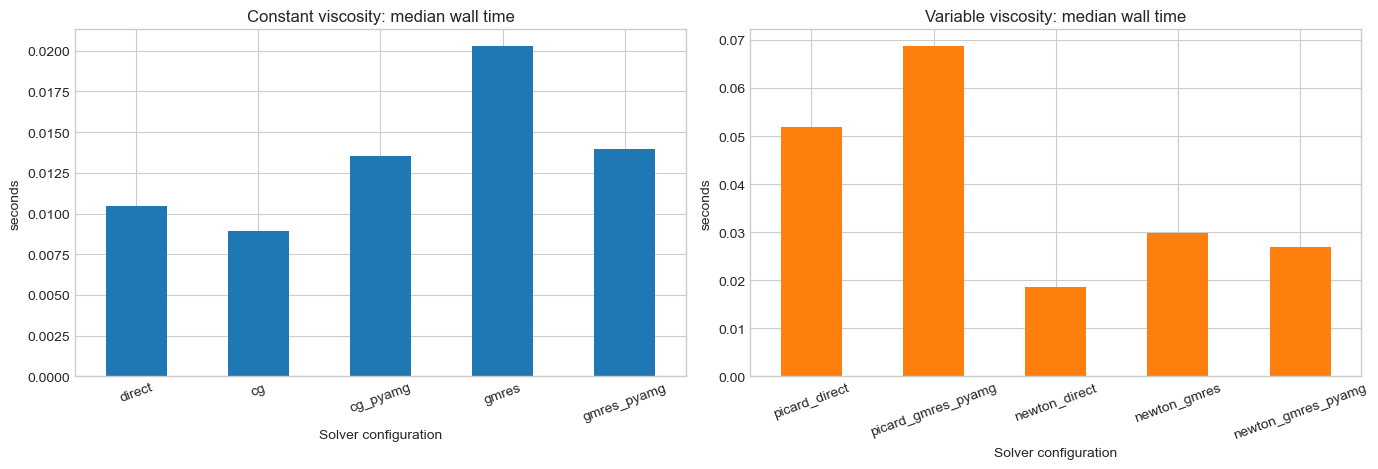

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))

constant_df.plot(
    x="config",
    y="time_median_s",
    kind="bar",
    ax=axes[0],
    legend=False,
    color="tab:blue",
    rot=20,
)
axes[0].set_title("Constant viscosity: median wall time")
axes[0].set_xlabel("Solver configuration")
axes[0].set_ylabel("seconds")

variable_df.plot(
    x="config",
    y="time_median_s",
    kind="bar",
    ax=axes[1],
    legend=False,
    color="tab:orange",
    rot=20,
)
axes[1].set_title("Variable viscosity: median wall time")
axes[1].set_xlabel("Solver configuration")
axes[1].set_ylabel("seconds")

plt.tight_layout()
fig.savefig(OUTPUT_DIR / "solver_runtime_bars.png", dpi=170, bbox_inches="tight")
finalize_figure(fig)

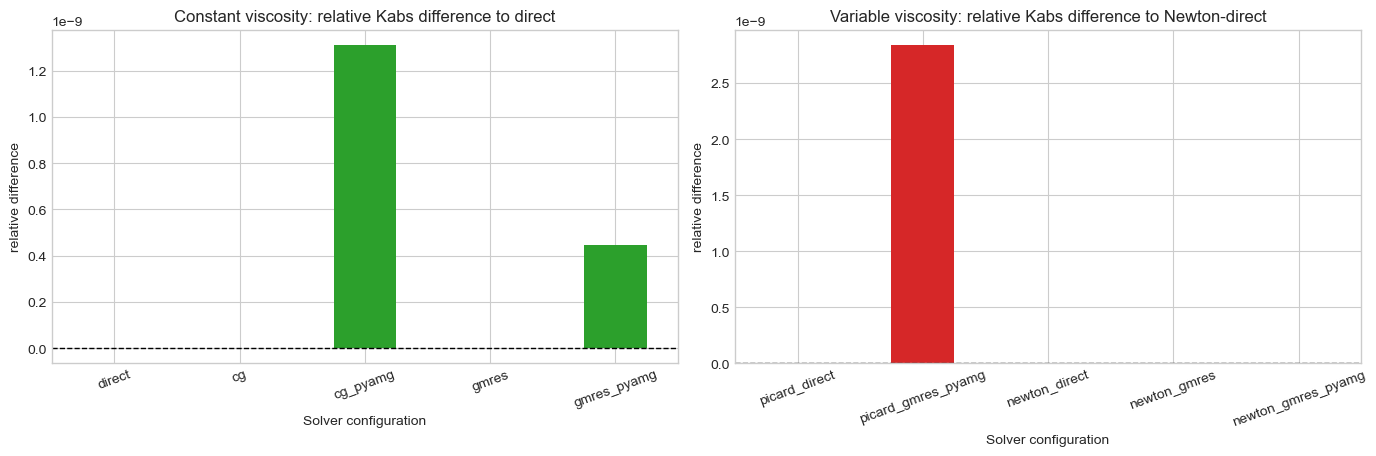

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))

constant_df.plot(
    x="config",
    y="kabs_rel_diff_to_reference",
    kind="bar",
    ax=axes[0],
    legend=False,
    color="tab:green",
    rot=20,
)
axes[0].axhline(0.0, color="k", linestyle="--", linewidth=1.0)
axes[0].set_title("Constant viscosity: relative Kabs difference to direct")
axes[0].set_xlabel("Solver configuration")
axes[0].set_ylabel("relative difference")

variable_df.plot(
    x="config",
    y="kabs_rel_diff_to_reference",
    kind="bar",
    ax=axes[1],
    legend=False,
    color="tab:red",
    rot=20,
)
axes[1].axhline(0.0, color="k", linestyle="--", linewidth=1.0)
axes[1].set_title("Variable viscosity: relative Kabs difference to Newton-direct")
axes[1].set_xlabel("Solver configuration")
axes[1].set_ylabel("relative difference")

plt.tight_layout()
fig.savefig(OUTPUT_DIR / "solver_accuracy_bars.png", dpi=170, bbox_inches="tight")
finalize_figure(fig)

## Pareto-style view: accuracy vs runtime

The reference solves sit at zero relative error by construction. The more interesting question is
whether faster iterative/preconditioned configurations stay close enough to the same `Kabs`.

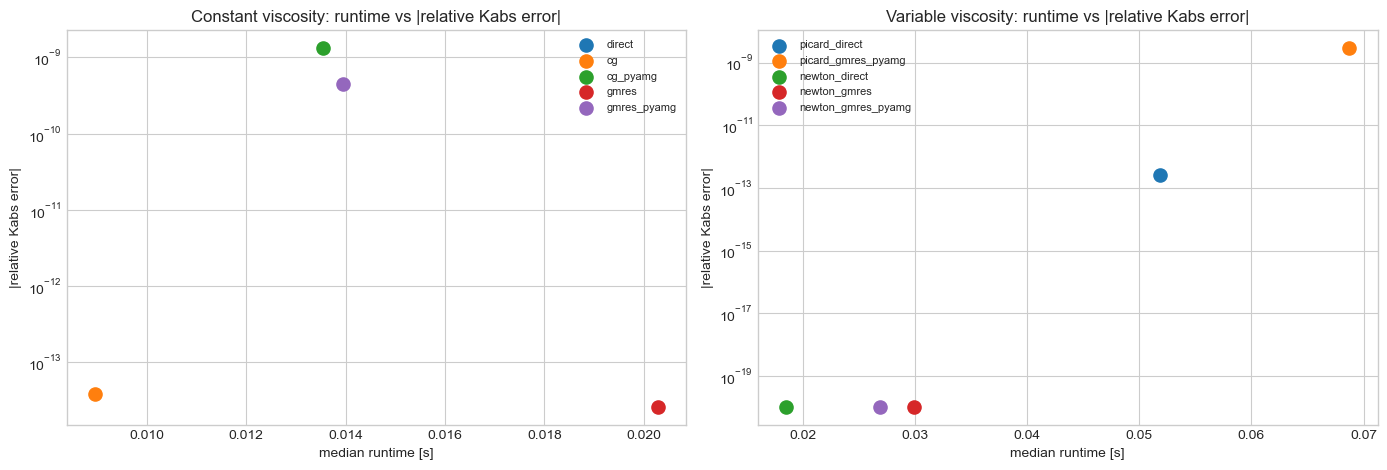

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))

for row in constant_df.itertuples(index=False):
    axes[0].scatter(
        row.time_median_s,
        abs(row.kabs_rel_diff_to_reference),
        s=90,
        label=row.config,
    )
axes[0].set_title("Constant viscosity: runtime vs |relative Kabs error|")
axes[0].set_xlabel("median runtime [s]")
axes[0].set_ylabel("|relative Kabs error|")
axes[0].set_yscale("log")
axes[0].legend(fontsize=8)

for row in variable_df.itertuples(index=False):
    axes[1].scatter(
        row.time_median_s,
        abs(row.kabs_rel_diff_to_reference) + 1.0e-20,
        s=90,
        label=row.config,
    )
axes[1].set_title("Variable viscosity: runtime vs |relative Kabs error|")
axes[1].set_xlabel("median runtime [s]")
axes[1].set_ylabel("|relative Kabs error|")
axes[1].set_yscale("log")
axes[1].legend(fontsize=8)

plt.tight_layout()
fig.savefig(
    OUTPUT_DIR / "runtime_vs_accuracy_scatter.png", dpi=170, bbox_inches="tight"
)
finalize_figure(fig)

## Nonlinear iteration count

For the variable-viscosity problem, wall time alone can be misleading. The next chart separates the
outer nonlinear work from the cost of each inner linear solve.

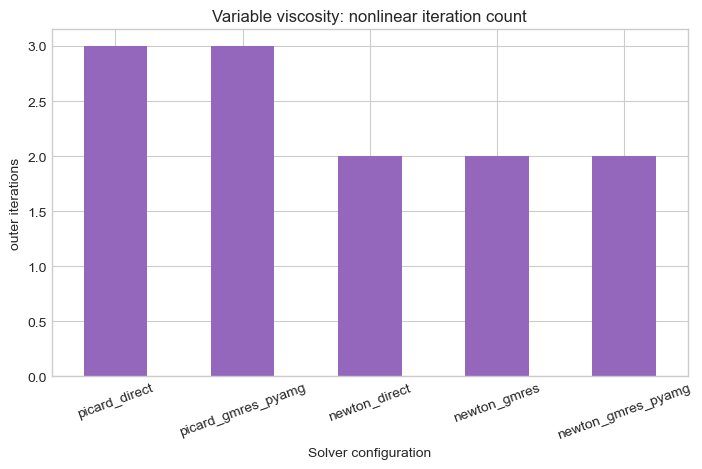

In [19]:
fig, ax = plt.subplots(figsize=(7.2, 4.8))
variable_df.plot(
    x="config",
    y="nonlinear_iterations",
    kind="bar",
    ax=ax,
    legend=False,
    color="tab:purple",
    rot=20,
)
ax.set_title("Variable viscosity: nonlinear iteration count")
ax.set_xlabel("Solver configuration")
ax.set_ylabel("outer iterations")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "nonlinear_iterations.png", dpi=170, bbox_inches="tight")
finalize_figure(fig)

## PyAMG speedup factors

These ratios are often more interpretable than raw times because they answer the practical question:
"How much do I gain from turning AMG on?"

In [20]:
speedup_rows = []
if {"cg", "cg_pyamg"}.issubset(constant_df["config"].tolist()):
    base = float(
        constant_df.loc[constant_df["config"] == "cg", "time_median_s"].iloc[0]
    )
    accelerated = float(
        constant_df.loc[constant_df["config"] == "cg_pyamg", "time_median_s"].iloc[0]
    )
    speedup_rows.append({"case": "constant_cg", "speedup": base / accelerated})
if {"gmres", "gmres_pyamg"}.issubset(constant_df["config"].tolist()):
    base = float(
        constant_df.loc[constant_df["config"] == "gmres", "time_median_s"].iloc[0]
    )
    accelerated = float(
        constant_df.loc[constant_df["config"] == "gmres_pyamg", "time_median_s"].iloc[0]
    )
    speedup_rows.append({"case": "constant_gmres", "speedup": base / accelerated})
if {"newton_gmres", "newton_gmres_pyamg"}.issubset(variable_df["config"].tolist()):
    base = float(
        variable_df.loc[variable_df["config"] == "newton_gmres", "time_median_s"].iloc[
            0
        ]
    )
    accelerated = float(
        variable_df.loc[
            variable_df["config"] == "newton_gmres_pyamg", "time_median_s"
        ].iloc[0]
    )
    speedup_rows.append({"case": "newton_gmres", "speedup": base / accelerated})
speedup_df = pd.DataFrame(speedup_rows)
speedup_df

,case,speedup
0,constant_cg,0.661247
1,constant_gmres,1.455238
2,newton_gmres,1.113059


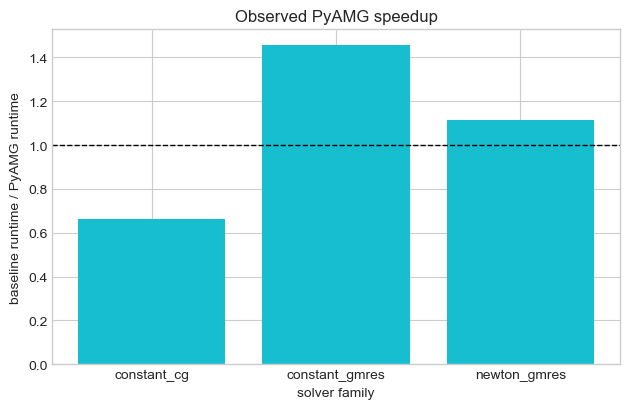

In [21]:
fig, ax = plt.subplots(figsize=(6.4, 4.2))
ax.bar(speedup_df["case"], speedup_df["speedup"], color="tab:cyan")
ax.axhline(1.0, color="k", linestyle="--", linewidth=1.0)
ax.set_title("Observed PyAMG speedup")
ax.set_xlabel("solver family")
ax.set_ylabel("baseline runtime / PyAMG runtime")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "pyamg_speedup.png", dpi=170, bbox_inches="tight")
finalize_figure(fig)

## Reading the tables

Suggested interpretation:
- for constant viscosity, the main question is whether `cg + pyamg` or `gmres + pyamg` reduces
  runtime without changing `Kabs`
- for variable viscosity, the main question is whether Newton reduces outer iterations enough to
  offset the cost of assembling and solving the exact Jacobian
- if the `Kabs` differences remain near machine precision, the benchmark is comparing numerics, not
  changing the physics

Suggested documentation use:
- the runtime bars are the high-level headline figure
- the runtime-vs-accuracy scatter is the defensible numerical-quality figure
- the nonlinear-iteration bar chart explains why Newton may outperform Picard even when each Newton
  iteration is more expensive